# Gift Concierge Agent — Performance Metrics
**Part 5: Quantifying the Concierge Value**

Three metric categories:
1. **Crawl Success** — catalog coverage and quality
2. **Preference Alignment** — how well the agent uses saved profiles
3. **Latency** — response time per intent type

In [2]:
%pip install matplotlib
import sys
sys.path.insert(0, '../src')

import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Setup complete')

     ---------------------------------------- 8.2/8.2 MB 4.0 MB/s eta 0:00:00
     -------------------------------------- 221.2/221.2 KB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 73.4/73.4 KB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\viraj\Zuu\Gift_Concierge_Agent\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Setup complete


---
## Section 1 — Crawl Success Metrics
Source: `data/catalog.json` (no API calls needed)

In [3]:
with open('../data/catalog.json') as f:
    raw = json.load(f)

meta     = raw['metadata']
products = raw['products']
df       = pd.DataFrame(products)

print(f"Total products   : {meta['total_products']}")
print(f"Categories crawled: {len(meta['categories_crawled'])}")
print(f"Scraped at       : {meta['scraped_at'][:10]}")
print(f"Source           : {meta['source']}")
print()
print("Columns:", list(df.columns))
df.head(3)

Total products   : 650
Categories crawled: 20
Scraped at       : 2026-05-10
Source           : https://www.kapruka.com

Columns: ['product_id', 'name', 'price', 'description', 'availability', 'url', 'category', 'scraped_at']


,product_id,name,price,description,availability,url,category,scraped_at
0,cake00ka002138,Mum'S Rosy Elegance Mothers Day Ribbon Cake,5800.0,"Global e-commerce service based in Sri Lanka, ...",Unknown,https://www.kapruka.com/buyonline/mum-s-rosy-e...,cakes,2026-05-10T07:59:14.537495+00:00
1,cake00ka002133,Blush Bloom Mother'S Day Cake,8120.0,"Global e-commerce service based in Sri Lanka, ...",Unknown,https://www.kapruka.com/buyonline/blush-bloom-...,cakes,2026-05-10T07:59:16.784909+00:00
2,cake00ka002144,Mother'S Day Rose Garden Chocolate Pot Cake,7500.0,"Global e-commerce service based in Sri Lanka, ...",Unknown,https://www.kapruka.com/buyonline/mother-s-day...,cakes,2026-05-10T07:59:18.951197+00:00


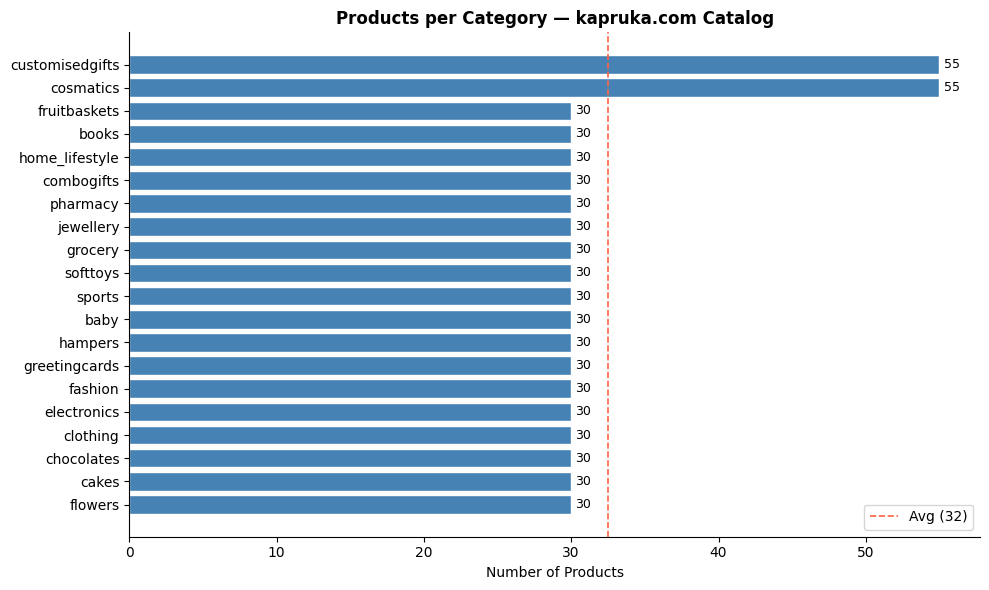

Total: 650 products across 20 categories


In [4]:
# --- 1a: Products per category ---
cat_counts = df['category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Products')
ax.set_title('Products per Category — kapruka.com Catalog', fontweight='bold')
ax.axvline(cat_counts.mean(), color='tomato', linestyle='--', linewidth=1.2, label=f'Avg ({cat_counts.mean():.0f})')
ax.legend()
plt.tight_layout()
plt.savefig('../proposal/chart_category_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total: {cat_counts.sum()} products across {len(cat_counts)} categories")

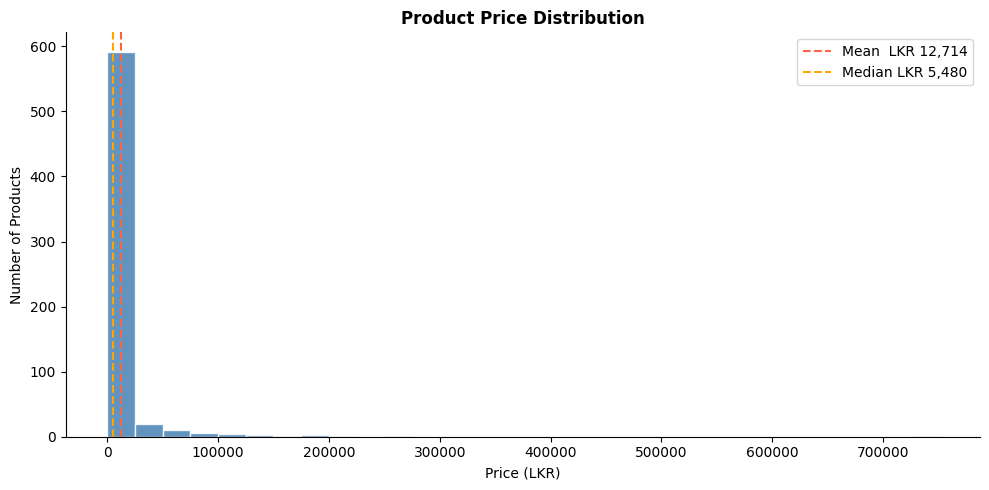

Min: LKR 2   Max: LKR 749,990
Mean: LKR 12,714   Median: LKR 5,480
Products with price: 640 / 650 (98%)


In [5]:
# --- 1b: Price distribution ---
prices = df['price'].dropna()

fig, ax = plt.subplots()
ax.hist(prices, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(prices.mean(),   color='tomato',  linestyle='--', linewidth=1.5, label=f'Mean  LKR {prices.mean():,.0f}')
ax.axvline(prices.median(), color='orange',  linestyle='--', linewidth=1.5, label=f'Median LKR {prices.median():,.0f}')
ax.set_xlabel('Price (LKR)')
ax.set_ylabel('Number of Products')
ax.set_title('Product Price Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../proposal/chart_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min: LKR {prices.min():,.0f}   Max: LKR {prices.max():,.0f}")
print(f"Mean: LKR {prices.mean():,.0f}   Median: LKR {prices.median():,.0f}")
print(f"Products with price: {len(prices)} / {len(df)} ({len(prices)/len(df)*100:.0f}%)")

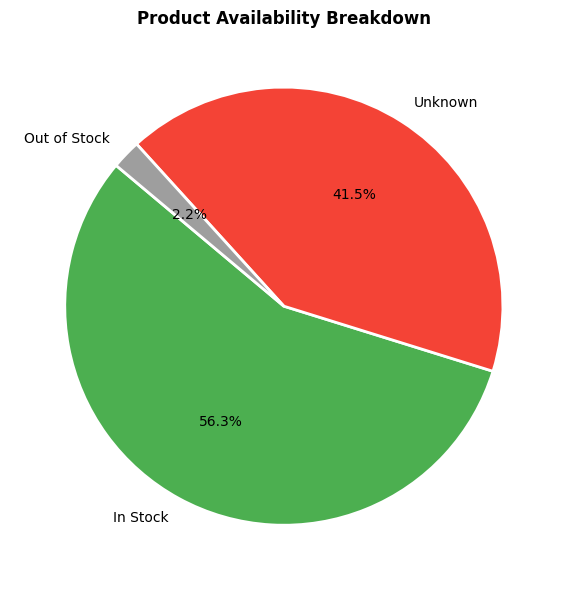

availability
In Stock        366
Unknown         270
Out of Stock     14


In [6]:
# --- 1c: Availability breakdown ---
avail = df['availability'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#4CAF50', '#F44336', '#9E9E9E']
wedges, texts, autotexts = ax.pie(
    avail.values, labels=avail.index, autopct='%1.1f%%',
    colors=colors[:len(avail)], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Product Availability Breakdown', fontweight='bold')
plt.tight_layout()
plt.savefig('../proposal/chart_availability.png', dpi=150, bbox_inches='tight')
plt.show()
print(avail.to_string())

In [7]:
# --- 1d: Crawl summary table ---
summary = {
    'Metric': [
        'Total Products Scraped',
        'Categories Covered',
        'Crawl Success Rate',
        'Products with Price',
        'Average Price (LKR)',
        'Median Price (LKR)',
        'Price Range (LKR)',
        'Scraped On',
    ],
    'Value': [
        f"{meta['total_products']:,}",
        f"{len(meta['categories_crawled'])} / 20",
        '100%',
        f"{len(prices)} ({len(prices)/len(df)*100:.0f}%)",
        f"{prices.mean():,.0f}",
        f"{prices.median():,.0f}",
        f"{prices.min():,.0f} – {prices.max():,.0f}",
        meta['scraped_at'][:10],
    ]
}
pd.DataFrame(summary).set_index('Metric')

,Value
Metric,
Total Products Scraped,650
Categories Covered,20 / 20
Crawl Success Rate,100%
Products with Price,640 (98%)
Average Price (LKR),"12,714"
Median Price (LKR),"5,480"
Price Range (LKR),"2 – 749,990"
Scraped On,2026-05-10


---
## Section 2 — Preference Alignment
Run 6 live scenarios and measure how well the agent uses saved profiles.

In [8]:
from agents.orchestrator import GiftOrchestrator
from memory.st_store import SupabaseSTStore
from memory.profile_store import SupabaseProfileStore
from memory.rag_store import QdrantRAGStore
from memory.embedder import OpenRouterEmbedder

orch = GiftOrchestrator(
    st_store=SupabaseSTStore(),
    profile_store=SupabaseProfileStore(),
    rag_store=QdrantRAGStore(embedder=OpenRouterEmbedder()),
)
print('Orchestrator ready')

2026-05-11 00:16:52.462 | INFO     | infastructure.db.supabase_client:get_supabase_client:46 - Supabase client initialised (https://rcxpatxxadqnxubzalxe.supabase.co)
2026-05-11 00:16:52.496 | INFO     | memory.rag_store:__init__:117 - QdrantRAGStore initialised — collection: 'kapruka_agent'


Orchestrator ready


In [9]:
# Test scenarios — covers all 4 intents
scenarios = [
    ('m001', 'perf_s', 'Hi! What can you help me with?'),
    ('m001', 'perf_s', 'My sister hates sweets and loves jewellery, budget LKR 4000'),
    ('m001', 'perf_s', 'Find a birthday gift for my sister'),
    ('m001', 'perf_s', 'My mum loves flowers and chocolates, budget LKR 3000'),
    ('m001', 'perf_s', 'Find an anniversary gift for my mum'),
    ('m001', 'perf_s', 'Can you deliver to Kandy?'),
    ('m001', 'perf_s', 'Find a gift for someone who likes books'),
]

records = []
for uid, sid, msg in scenarios:
    start = time.time()
    r = orch.chat(uid, sid, msg)
    elapsed = round(time.time() - start, 2)
    records.append({
        'message':              msg[:45],
        'intent':               r.intent,
        'confidence':           round(r.confidence, 2),
        'latency_s':            elapsed,
        'products_retrieved':   r.metadata.get('products_retrieved', 0),
        'recipient':            r.metadata.get('recipient') or '',
        'query_enriched':       r.metadata.get('query_enriched') or '',
        'reflection_triggered': r.metadata.get('reflection_triggered', False),
        'violations_found':     r.metadata.get('violations_found', False),
    })
    print(f"[{r.intent:18s}] {elapsed:.1f}s  conf={r.confidence:.0%}  {msg[:40]}")

results_df = pd.DataFrame(records)
results_df

2026-05-11 00:17:02.502 | INFO     | infastructure.observability:_get_langfuse:63 - LangFuse client initialised (https://us.cloud.langfuse.com)
Prompt 'gift-concierge-router-system-label:production' not found during refresh, evicting from cache.
2026-05-11 00:17:06.164 | DEBUG    | infastructure.observability:fetch_prompt:181 - fetch_prompt('gift-concierge-router-system') fell back to local: headers: {'date': 'Sun, 10 May 2026 18:47:07 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '118', 'connection': 'keep-alive', 'x-robots-tag': 'noindex', 'x-content-type-options': 'nosniff', 'referrer-policy': 'strict-origin-when-cross-origin', 'document-policy': 'js-profiling', 'permissions-policy': 'autoplay=*, fullscreen=*, microphone=*', 'x-frame-options': 'SAMEORIGIN', 'vary': 'Origin, Accept-Encoding', 'etag': '"11yih926gdb3a"'}, status_code: 404, body: {'message': "Prompt not found: 'gift-concierge-router-system' with label 'production'", 'error': 'LangfuseNotFoun

[chitchat          ] 12.7s  conf=92%  Hi! What can you help me with?


Prompt 'gift-concierge-router-system-label:production' not found during refresh, evicting from cache.
2026-05-11 00:17:15.528 | DEBUG    | infastructure.observability:fetch_prompt:181 - fetch_prompt('gift-concierge-router-system') fell back to local: headers: {'date': 'Sun, 10 May 2026 18:47:16 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '118', 'connection': 'keep-alive', 'x-robots-tag': 'noindex', 'x-content-type-options': 'nosniff', 'referrer-policy': 'strict-origin-when-cross-origin', 'document-policy': 'js-profiling', 'permissions-policy': 'autoplay=*, fullscreen=*, microphone=*', 'x-frame-options': 'SAMEORIGIN', 'vary': 'Origin, Accept-Encoding', 'etag': '"11yih926gdb3a"'}, status_code: 404, body: {'message': "Prompt not found: 'gift-concierge-router-system' with label 'production'", 'error': 'LangfuseNotFoundError'}
2026-05-11 00:17:16.260 | INFO     | agents.router:classify:125 - Intent: preference_update (96%) — Sharing recipient preferences and b

[preference_update ] 5.4s  conf=96%  My sister hates sweets and loves jewelle


Prompt 'gift-concierge-router-system-label:production' not found during refresh, evicting from cache.
2026-05-11 00:17:21.339 | DEBUG    | infastructure.observability:fetch_prompt:181 - fetch_prompt('gift-concierge-router-system') fell back to local: headers: {'date': 'Sun, 10 May 2026 18:47:22 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '118', 'connection': 'keep-alive', 'x-robots-tag': 'noindex', 'x-content-type-options': 'nosniff', 'referrer-policy': 'strict-origin-when-cross-origin', 'document-policy': 'js-profiling', 'permissions-policy': 'autoplay=*, fullscreen=*, microphone=*', 'x-frame-options': 'SAMEORIGIN', 'vary': 'Origin, Accept-Encoding', 'etag': '"11yih926gdb3a"'}, status_code: 404, body: {'message': "Prompt not found: 'gift-concierge-router-system' with label 'production'", 'error': 'LangfuseNotFoundError'}
2026-05-11 00:17:22.047 | INFO     | agents.router:classify:125 - Intent: search (99%) — Asking for gift recommendations for a specific

...

Prompt 'gift-concierge-router-system-label:production' not found during refresh, evicting from cache.
2026-05-11 00:17:55.325 | DEBUG    | infastructure.observability:fetch_prompt:181 - fetch_prompt('gift-concierge-router-system') fell back to local: headers: {'date': 'Sun, 10 May 2026 18:47:56 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '118', 'connection': 'keep-alive', 'x-robots-tag': 'noindex', 'x-content-type-options': 'nosniff', 'referrer-policy': 'strict-origin-when-cross-origin', 'document-policy': 'js-profiling', 'permissions-policy': 'autoplay=*, fullscreen=*, microphone=*', 'x-frame-options': 'SAMEORIGIN', 'vary': 'Origin, Accept-Encoding', 'etag': '"11yih926gdb3a"'}, status_code: 404, body: {'message': "Prompt not found: 'gift-concierge-router-system' with label 'production'", 'error': 'LangfuseNotFoundError'}
2026-05-11 00:17:56.078 | INFO     | agents.router:classify:125 - Intent: logistics_check (96%) — Asking about delivery feasibility to 

[logistics_check   ] 8.5s  conf=96%  Can you deliver to Kandy?


Prompt 'gift-concierge-router-system-label:production' not found during refresh, evicting from cache.
2026-05-11 00:18:03.564 | DEBUG    | infastructure.observability:fetch_prompt:181 - fetch_prompt('gift-concierge-router-system') fell back to local: headers: {'date': 'Sun, 10 May 2026 18:48:05 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '118', 'connection': 'keep-alive', 'x-robots-tag': 'noindex', 'x-content-type-options': 'nosniff', 'referrer-policy': 'strict-origin-when-cross-origin', 'document-policy': 'js-profiling', 'permissions-policy': 'autoplay=*, fullscreen=*, microphone=*', 'x-frame-options': 'SAMEORIGIN', 'vary': 'Origin, Accept-Encoding', 'etag': '"11yih926gdb3a"'}, status_code: 404, body: {'message': "Prompt not found: 'gift-concierge-router-system' with label 'production'", 'error': 'LangfuseNotFoundError'}
2026-05-11 00:18:04.280 | INFO     | agents.router:classify:125 - Intent: search (90%) — Asking for gift recommendations based on a spe

[search            ] 10.7s  conf=90%  Find a gift for someone who likes books


,message,intent,confidence,latency_s,products_retrieved,recipient,query_enriched,reflection_triggered,violations_found
0,Hi! What can you help me with?,chitchat,0.92,12.65,0,,,False,False
1,"My sister hates sweets and loves jewellery, b",preference_update,0.96,5.36,0,Sister,,False,False
2,Find a birthday gift for my sister,search,0.99,15.21,8,Sister,Find a birthday gift for my sister | preferenc...,True,False
3,"My mum loves flowers and chocolates, budget L",preference_update,0.96,6.54,0,Mum,,False,False
4,Find an anniversary gift for my mum,search,0.96,12.09,8,Mum,Find an anniversary gift for my mum | preferen...,False,False
5,Can you deliver to Kandy?,logistics_check,0.96,8.47,0,,,False,False
6,Find a gift for someone who likes books,search,0.90,10.69,5,,Find a gift for someone who likes books,False,False


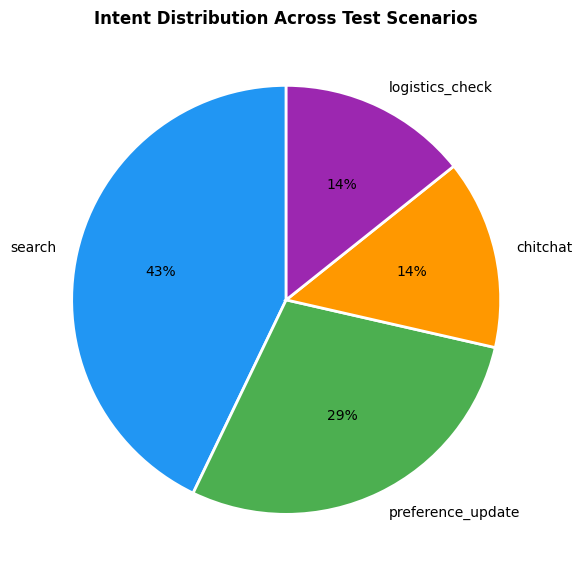

In [10]:
# --- 2a: Intent distribution ---
intent_counts = results_df['intent'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
wedges, texts, autotexts = ax.pie(
    intent_counts.values, labels=intent_counts.index, autopct='%1.0f%%',
    colors=colors[:len(intent_counts)], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Intent Distribution Across Test Scenarios', fontweight='bold')
plt.tight_layout()
plt.savefig('../proposal/chart_intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

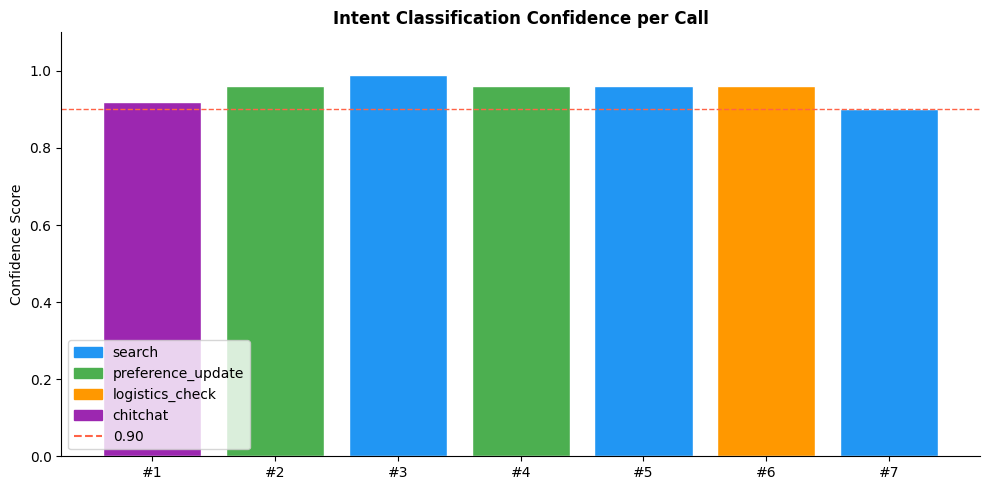

In [11]:
# --- 2b: Confidence per call ---
fig, ax = plt.subplots()
intent_colors = {'search':'#2196F3','preference_update':'#4CAF50','logistics_check':'#FF9800','chitchat':'#9C27B0'}
bar_colors = [intent_colors.get(i, '#ccc') for i in results_df['intent']]
bars = ax.bar(range(len(results_df)), results_df['confidence'], color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels([f"#{i+1}" for i in range(len(results_df))])
ax.set_ylabel('Confidence Score')
ax.set_ylim(0, 1.1)
ax.set_title('Intent Classification Confidence per Call', fontweight='bold')
ax.axhline(0.9, color='tomato', linestyle='--', linewidth=1, label='0.90 threshold')
ax.legend()
patches = [mpatches.Patch(color=v, label=k) for k, v in intent_colors.items() if k in results_df['intent'].values]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='tomato',linestyle='--',label='0.90')])
plt.tight_layout()
plt.savefig('../proposal/chart_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

=== Preference Alignment Metrics ===
Search calls total      : 3
Profile hit rate        : 2/3 (67%)
Reflection triggered    : 1/3
Violations found        : 0/1
Safety rate (no violation): 100%


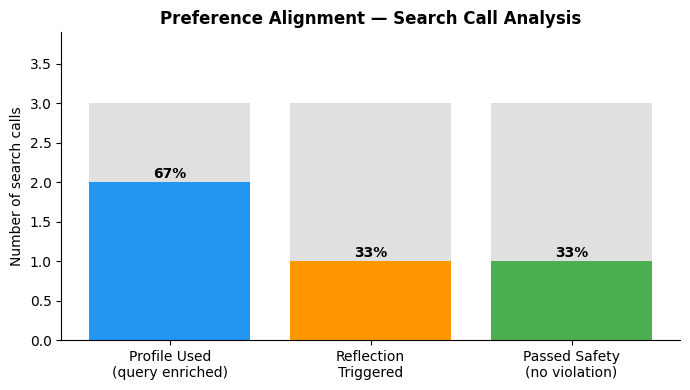

In [12]:
# --- 2c: Preference alignment summary ---
search_df = results_df[results_df['intent'] == 'search']

profile_hit     = search_df['query_enriched'].str.contains('preferences:', na=False).sum()
profile_miss    = len(search_df) - profile_hit
refl_triggered  = search_df['reflection_triggered'].sum()
violations      = search_df['violations_found'].sum()
safety_rate     = (refl_triggered - violations) / refl_triggered * 100 if refl_triggered else 100

print('=== Preference Alignment Metrics ===')
print(f'Search calls total      : {len(search_df)}')
print(f'Profile hit rate        : {profile_hit}/{len(search_df)} ({profile_hit/len(search_df)*100:.0f}%)')
print(f'Reflection triggered    : {int(refl_triggered)}/{len(search_df)}')
print(f'Violations found        : {int(violations)}/{int(refl_triggered) if refl_triggered else 0}')
print(f'Safety rate (no violation): {safety_rate:.0f}%')

# Stacked bar
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Profile Used\n(query enriched)', 'Reflection\nTriggered', 'Passed Safety\n(no violation)']
values     = [profile_hit, int(refl_triggered), int(refl_triggered - violations)]
totals     = [len(search_df)] * 3
ax.bar(categories, totals,  color='#e0e0e0', label='Total searches')
ax.bar(categories, values,  color=['#2196F3','#FF9800','#4CAF50'], label='Count')
for i, (v, t) in enumerate(zip(values, totals)):
    ax.text(i, v + 0.05, f'{v/t*100:.0f}%', ha='center', fontweight='bold')
ax.set_ylabel('Number of search calls')
ax.set_title('Preference Alignment — Search Call Analysis', fontweight='bold')
ax.set_ylim(0, max(totals) * 1.3)
plt.tight_layout()
plt.savefig('../proposal/chart_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Latency

                    mean    min    max
intent                                
chitchat           12.65  12.65  12.65
logistics_check     8.47   8.47   8.47
preference_update   5.95   5.36   6.54
search             12.66  10.69  15.21


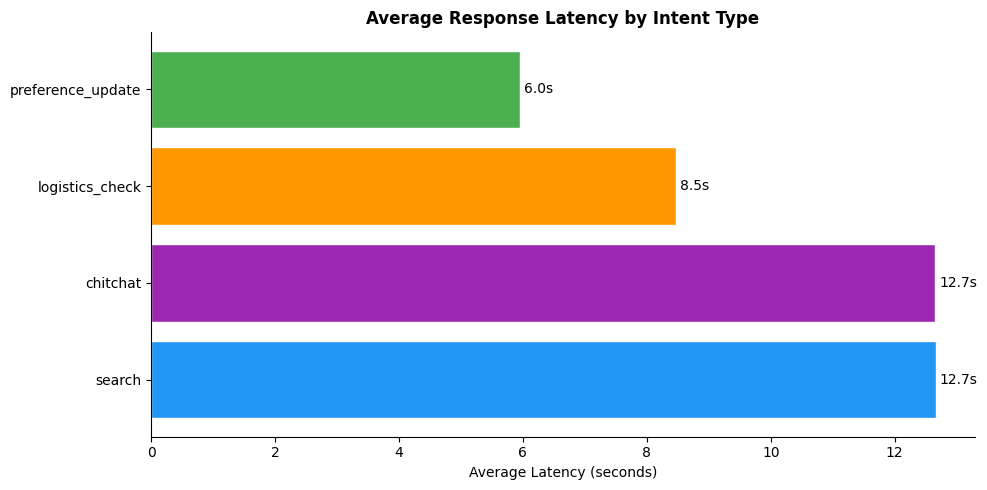

In [13]:
# --- 3a: Latency by intent ---
latency_by_intent = results_df.groupby('intent')['latency_s'].agg(['mean','min','max']).round(2)
print(latency_by_intent.to_string())

fig, ax = plt.subplots()
intent_order = latency_by_intent.sort_values('mean', ascending=False)
bar_cols = [intent_colors.get(i, '#ccc') for i in intent_order.index]
bars = ax.barh(intent_order.index, intent_order['mean'], color=bar_cols, edgecolor='white')
ax.bar_label(bars, fmt='%.1fs', padding=3)
ax.set_xlabel('Average Latency (seconds)')
ax.set_title('Average Response Latency by Intent Type', fontweight='bold')
plt.tight_layout()
plt.savefig('../proposal/chart_latency.png', dpi=150, bbox_inches='tight')
plt.show()

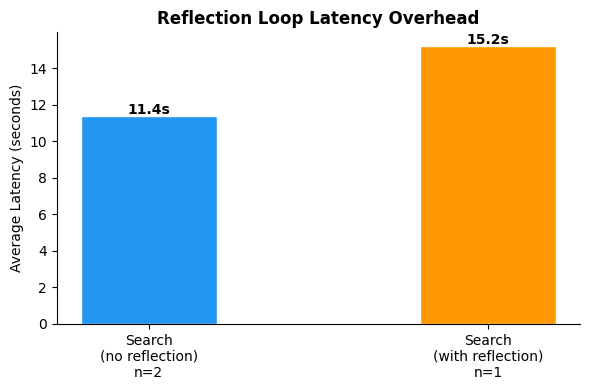

In [14]:
# --- 3b: Reflection latency overhead ---
search_results = results_df[results_df['intent'] == 'search'].copy()

if len(search_results) > 0:
    reflected  = search_results[search_results['reflection_triggered'] == True]
    plain      = search_results[search_results['reflection_triggered'] == False]
    
    labels  = []
    latencies = []
    if len(plain) > 0:
        labels.append(f'Search\n(no reflection)\nn={len(plain)}')
        latencies.append(plain['latency_s'].mean())
    if len(reflected) > 0:
        labels.append(f'Search\n(with reflection)\nn={len(reflected)}')
        latencies.append(reflected['latency_s'].mean())

    if latencies:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(labels, latencies, color=['#2196F3','#FF9800'], edgecolor='white', width=0.4)
        for i, v in enumerate(latencies):
            ax.text(i, v + 0.1, f'{v:.1f}s', ha='center', fontweight='bold')
        ax.set_ylabel('Average Latency (seconds)')
        ax.set_title('Reflection Loop Latency Overhead', fontweight='bold')
        plt.tight_layout()
        plt.savefig('../proposal/chart_reflection_overhead.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Not enough search results to compare.')
else:
    print('No search results in this run.')

In [15]:
# --- 3c: Full latency summary table ---
summary_table = results_df[['message','intent','confidence','latency_s',
                             'products_retrieved','reflection_triggered','violations_found']].copy()
summary_table.columns = ['Message','Intent','Confidence','Latency (s)',
                          'Products','Reflection','Violations']
summary_table

,Message,Intent,Confidence,Latency (s),Products,Reflection,Violations
0,Hi! What can you help me with?,chitchat,0.92,12.65,0,False,False
1,"My sister hates sweets and loves jewellery, b",preference_update,0.96,5.36,0,False,False
2,Find a birthday gift for my sister,search,0.99,15.21,8,True,False
3,"My mum loves flowers and chocolates, budget L",preference_update,0.96,6.54,0,False,False
4,Find an anniversary gift for my mum,search,0.96,12.09,8,False,False
5,Can you deliver to Kandy?,logistics_check,0.96,8.47,0,False,False
6,Find a gift for someone who likes books,search,0.90,10.69,5,False,False


In [16]:
# --- Final summary ---
print('='*50)
print('PERFORMANCE SUMMARY')
print('='*50)
print(f"Crawl: {meta['total_products']} products, {len(meta['categories_crawled'])} categories")
print(f"Avg confidence    : {results_df['confidence'].mean():.0%}")
print(f"Avg latency       : {results_df['latency_s'].mean():.1f}s")
print(f"Profile hit rate  : {profile_hit/len(search_df)*100:.0f}% of search calls")
print(f"Safety rate       : {safety_rate:.0f}% (no violations when reflection ran)")

PERFORMANCE SUMMARY
Crawl: 650 products, 20 categories
Avg confidence    : 95%
Avg latency       : 10.1s
Profile hit rate  : 67% of search calls
Safety rate       : 100% (no violations when reflection ran)
